# Enterprise AI Meeting Assistant
### Notebook 1 — Preprocessing → Autoencoder → VAE → Transformer

This notebook covers the first half of the pipeline described in the project report:

```
AMI Audio → Preprocessing → Mel Spectrogram → AE / VAE
                          → ASR → Transcript → Transformer
```

GAN and Diffusion are implemented in separate follow-up files/notebooks once this
shared preprocessing + representation-learning foundation is validated.

**Files used by this notebook** (place them in the same folder):
- `preprocessing.py`
- `autoencoder.py`
- `vae.py`
- `transformer_pipeline.py`

**Security reminder:** never hard-code your Hugging Face token in this notebook.
Set it as an environment variable before launching Jupyter:
```bash
export HF_TOKEN="hf_xxx..."
```
If a token was ever exposed (e.g. committed to GitHub or pasted in a shared notebook),
revoke it immediately at https://huggingface.co/settings/tokens and generate a new one.


## 0. Install dependencies

Run once per environment.

In [1]:
!pip install -q torch torchaudio datasets transformers rouge-score bert-score soundfile librosa huggingface_hub



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Environment check
Confirms GPU/CPU availability and that the HF token is picked up from the environment
(never printed directly).

In [1]:
import os
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
print("HF_TOKEN set:", bool(os.getenv("HF_TOKEN")))


Torch version: 2.11.0+cu128
CUDA available: True
Device: cuda
HF_TOKEN set: False


## 2. Preprocessing — AMI Dataset → Mel Spectrogram tensors

Loads the AMI Meeting Corpus (`edinburghcstr/ami`, `ihm` config) in **streaming** mode
with automatic audio decoding **disabled** (`Audio(decode=False)`), so nothing is
fully downloaded and there are no TorchCodec DLL decode errors. A small, fixed-size
subset of raw examples is pulled per split, then each example's audio bytes are
decoded manually with `soundfile` before being converted to a Mel spectrogram.
then for each audio example:

1. Resamples to 16 kHz
2. Peak-normalizes the waveform
3. Chunks into 5-second segments
4. Converts each chunk into a fixed-size log-Mel spectrogram (64 mels × 128 frames)
5. Min-max normalizes each spectrogram to `[0, 1]`

Produces `data/X_train.pt` (3000), `data/X_val.pt` (500), `data/X_test.pt` (500)
by default -- a small subset, not the full AMI corpus. Adjust `n_train`/`n_val`/`n_test`
in the next cell to change the subset size.

In [2]:
from preprocessing import run_pipeline, load_splits

# Run once to build and cache the tensors (skip this cell on subsequent runs
# and just call load_splits() instead).
# NOTE: this pulls a SMALL SUBSET via streaming (not the full AMI dataset),
# and audio is decoded manually inside preprocessing.py (Audio(decode=False)
# avoids TorchCodec DLL errors and unnecessary downloads).
X_train, X_val, X_test = run_pipeline(n_train=3000, n_val=500, n_test=500)


[WARN] HF_TOKEN not found in environment. Set it with `export HF_TOKEN=your_token` before running, or run `huggingface-cli login`.


c:\Users\Sakshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Streaming edinburghcstr/ami (ihm) from Hugging Face...


Dataset loaded in streaming mode (audio decoding deferred).

Creating small raw subsets (this does NOT download the full dataset)...

Raw subset sizes -> train: 3000, val: 500, test: 500

Decoding + converting to Mel spectrograms...

Saved tensors:
  X_train: torch.Size([3000, 1, 64, 128])
  X_val:   torch.Size([500, 1, 64, 128])
  X_test:  torch.Size([500, 1, 64, 128])


In [3]:
# On later runs, just reload the cached tensors instead of re-streaming AMI:
# X_train, X_val, X_test = load_splits()

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: torch.Size([3000, 1, 64, 128])
Val:   torch.Size([500, 1, 64, 128])
Test:  torch.Size([500, 1, 64, 128])


### 2.1 Visual sanity check
Plot a couple of Mel spectrograms to confirm preprocessing looks correct.

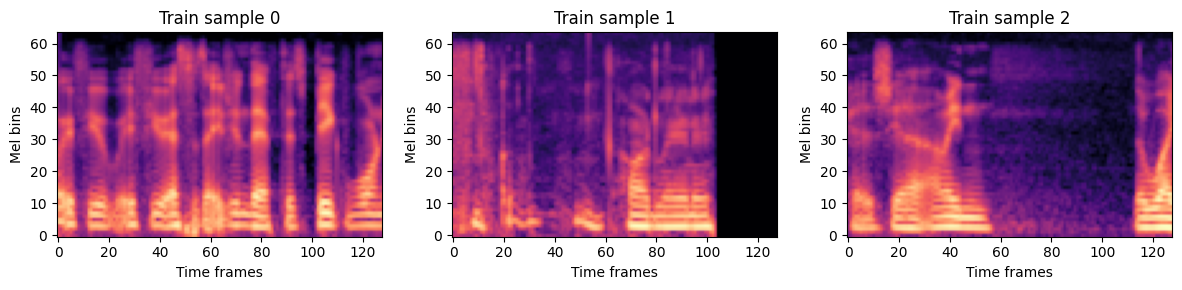

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i, 0].numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"Train sample {i}")
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
plt.tight_layout()
plt.show()


## 3. Autoencoder (AE)

Compresses each Mel spectrogram into a latent vector and reconstructs it.
Loss: `MSE(X, X_hat)`. Evaluated with MSE, MAE, RMSE, PSNR, and a lightweight SSIM.

In [7]:
from autoencoder import train_autoencoder

ae_model, ae_history, ae_test_metrics = train_autoencoder(
    epochs=70,
    batch_size=16,
    latent_dim=256,
    lr=1e-3,
)


[AE] Epoch 001/70 | train_MSE=0.03447 | val_MSE=0.01793 * | val_PSNR=17.46 dB | val_SSIM=0.823 | lr=1.00e-03
[AE] Epoch 002/70 | train_MSE=0.01601 | val_MSE=0.01325 * | val_PSNR=18.78 dB | val_SSIM=0.874 | lr=1.00e-03
[AE] Epoch 003/70 | train_MSE=0.01213 | val_MSE=0.01113 * | val_PSNR=19.53 dB | val_SSIM=0.889 | lr=1.00e-03
[AE] Epoch 004/70 | train_MSE=0.01011 | val_MSE=0.00945 * | val_PSNR=20.24 dB | val_SSIM=0.913 | lr=1.00e-03
[AE] Epoch 005/70 | train_MSE=0.00910 | val_MSE=0.00877 * | val_PSNR=20.57 dB | val_SSIM=0.919 | lr=1.00e-03
[AE] Epoch 006/70 | train_MSE=0.00825 | val_MSE=0.00800 * | val_PSNR=20.97 dB | val_SSIM=0.924 | lr=1.00e-03
[AE] Epoch 007/70 | train_MSE=0.00765 | val_MSE=0.00822 | val_PSNR=20.85 dB | val_SSIM=0.921 | lr=1.00e-03
[AE] Epoch 008/70 | train_MSE=0.00739 | val_MSE=0.00742 * | val_PSNR=21.29 dB | val_SSIM=0.931 | lr=1.00e-03
[AE] Epoch 009/70 | train_MSE=0.00697 | val_MSE=0.00755 | val_PSNR=21.22 dB | val_SSIM=0.929 | lr=1.00e-03
[AE] Epoch 010/70 | tra

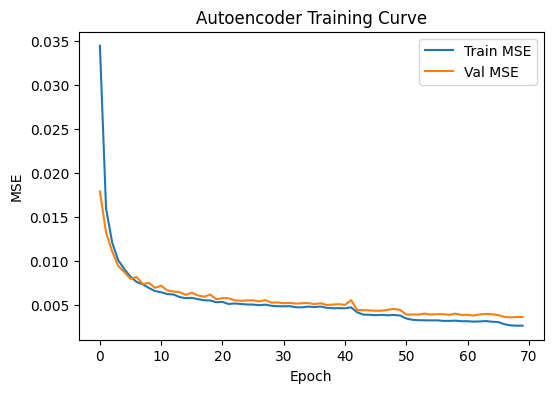

AE Test Metrics:
  MSE: 0.00293
  MAE: 0.03345
  RMSE: 0.05409
  PSNR: 25.33807
  SSIM: 0.97464


In [8]:
plt.figure(figsize=(6, 4))
plt.plot(ae_history["train_loss"], label="Train MSE")
plt.plot(ae_history["val_mse"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder Training Curve")
plt.legend()
plt.show()

print("AE Test Metrics:")
for k, v in ae_test_metrics.items():
    print(f"  {k}: {v:.5f}")


### 3.1 Reconstruction quality check
Compare an original Mel spectrogram against its AE reconstruction.

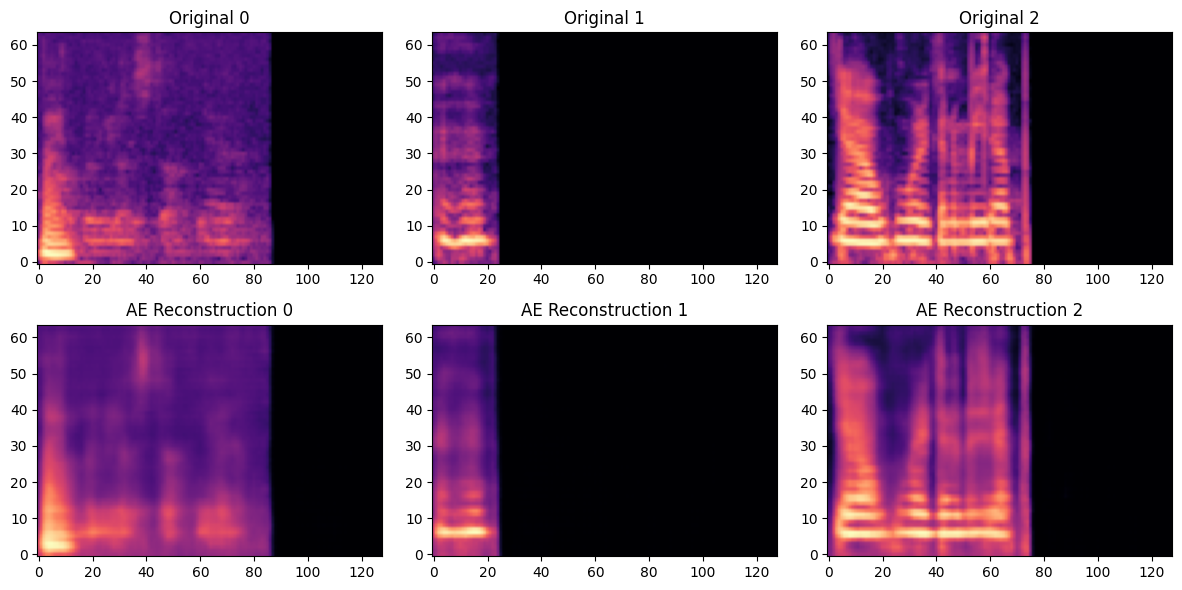

In [9]:
ae_model.eval()
with torch.no_grad():
    sample = X_test[:3].to(next(ae_model.parameters()).device)
    recon, _ = ae_model(sample)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i in range(3):
    axes[0, i].imshow(sample[i, 0].cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[0, i].set_title(f"Original {i}")
    axes[1, i].imshow(recon[i, 0].cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    axes[1, i].set_title(f"AE Reconstruction {i}")
plt.tight_layout()
plt.show()


## 4. Variational Autoencoder (VAE)

Learns a **probabilistic** latent distribution `N(mu, sigma^2)` instead of a single
fixed vector, using the reparameterization trick `z = mu + sigma * epsilon`.

Loss: `L_VAE = L_recon + beta * L_KL`
- `L_recon` — MSE reconstruction loss
- `L_KL` — KL divergence between `q(z|x)` and the prior `N(0, I)`

In [12]:
from vae import train_vae

vae_model, vae_history, vae_test_metrics = train_vae(
    epochs=70,
    batch_size=16,
    latent_dim=256,
    lr=1e-3,
    beta=0.6,
)


[VAE] Epoch 001/70 | train_loss=406.4821 | val_total=184.4113 * | val_recon=149.4505 | val_KL=58.2680 (0.2276/dim) | val_MSE=0.01809 | lr=1.00e-03
[VAE] Epoch 002/70 | train_loss=176.2333 | val_total=159.4850 * | val_recon=136.6072 | val_KL=38.1298 (0.1489/dim) | val_MSE=0.01656 | lr=1.00e-03
[VAE] Epoch 003/70 | train_loss=156.8387 | val_total=149.8195 * | val_recon=127.6864 | val_KL=36.8885 (0.1441/dim) | val_MSE=0.01547 | lr=1.00e-03
[VAE] Epoch 004/70 | train_loss=146.5730 | val_total=142.9030 * | val_recon=116.8549 | val_KL=43.4135 (0.1696/dim) | val_MSE=0.01418 | lr=1.00e-03
[VAE] Epoch 005/70 | train_loss=139.3343 | val_total=137.8742 * | val_recon=112.2169 | val_KL=42.7623 (0.1670/dim) | val_MSE=0.01362 | lr=1.00e-03
[VAE] Epoch 006/70 | train_loss=134.4150 | val_total=134.8104 * | val_recon=111.6995 | val_KL=38.5182 (0.1505/dim) | val_MSE=0.01357 | lr=1.00e-03
[VAE] Epoch 007/70 | train_loss=129.6494 | val_total=132.0722 * | val_recon=107.2672 | val_KL=41.3416 (0.1615/dim) | v

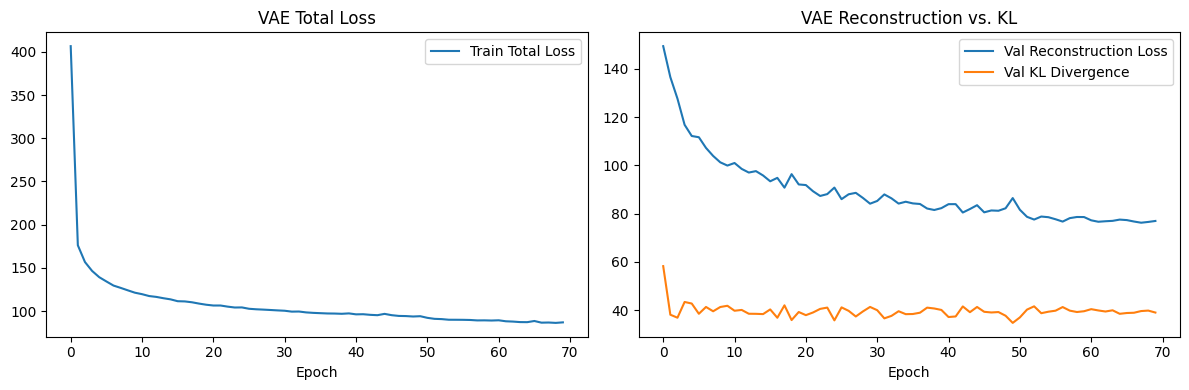

VAE Test Metrics:
  Total_Loss: 83.75809
  Reconstruction_Loss: 62.02304
  KL_Divergence: 36.22507
  KL_Divergence_Per_Dim: 0.14150
  MSE: 0.00752
  PSNR: 21.23828


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vae_history["train_loss"], label="Train Total Loss")
axes[0].set_title("VAE Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(vae_history["val_recon"], label="Val Reconstruction Loss")
axes[1].plot(vae_history["val_kl"], label="Val KL Divergence")
axes[1].set_title("VAE Reconstruction vs. KL")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

print("VAE Test Metrics:")
for k, v in vae_test_metrics.items():
    print(f"  {k}: {v:.5f}")


### 4.1 Generate new spectrograms from random noise
Because the VAE's latent space is regularized toward `N(0, I)`, we can sample
random latent vectors and decode them into *new* (never-seen) spectrograms.

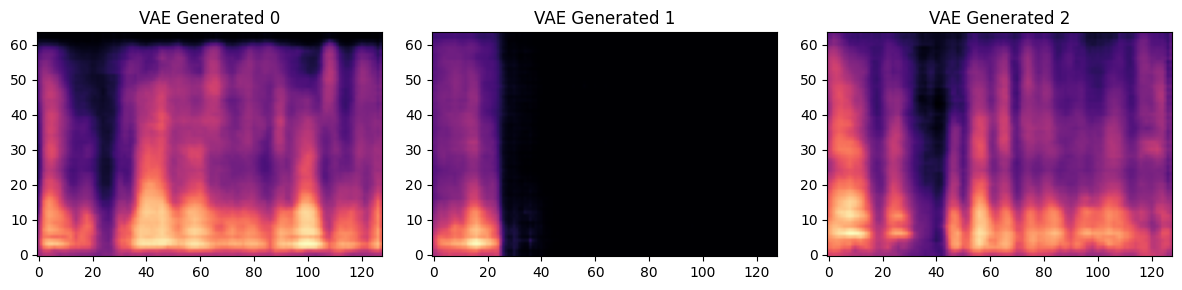

In [14]:
with torch.no_grad():
    generated = vae_model.sample(n=3, device=next(vae_model.parameters()).device)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(generated[i, 0].cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"VAE Generated {i}")
plt.tight_layout()
plt.show()


## 5. ASR + Transformer — Transcript, Summary, Decisions, Action Items

This stage is independent of the AE/VAE spectrogram pipeline above — it takes a
**raw meeting audio file** (not the preprocessed Mel tensors), runs Whisper for
speech-to-text, then prompts a pretrained FLAN-T5 Transformer to produce
structured outputs.

Replace `MEETING_AUDIO_PATH` with a path to an actual `.wav`/`.mp3`/`.flac` file.

In [16]:
!python export_sample_audio.py --out sample_meeting.wav --seconds 30

[WARN] HF_TOKEN not found in environment. Set it with `export HF_TOKEN=your_token` before running, or run `huggingface-cli login`.
Streaming edinburghcstr/ami (ihm) from Hugging Face...
Dataset loaded in streaming mode (audio decoding deferred).
Pulling one raw example from the 'train' split...
Saved 30s clip to sample_meeting.wav  (sample rate: 16000 Hz)
Meeting ID: EN2001a


In [3]:
!pip install tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.8 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.1 MB/s  0:00:00



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from transformer_pipeline import SpeechToText, MeetingTransformer

MEETING_AUDIO_PATH = "sample_meeting.wav"  # <-- update this path

stt = SpeechToText(model_name="openai/whisper-small")
transcript = stt.transcribe(MEETING_AUDIO_PATH)
print("=== TRANSCRIPT ===")
print(transcript)


c:\Users\Sakshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device set to use cuda:0
`return_token_timestamps` is deprecated for WhisperFeatureExtractor and will be removed in Transformers v5. Use `return_attention_mask` instead, as the number of frames can be inferred from it.
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


=== TRANSCRIPT ===
if you have this big warning about doing nothing at all in the gateway machine.


In [19]:
!pip install "transformers<5.0" --upgrade

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
    --------------------------------------- 0.3/12.0 MB ? eta -:--:--
    --------------------------------------- 0.3/12.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.0 MB 541.6 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.0 MB 541.6 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.0 MB 541.6 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.0 MB 500.8 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/12.0 MB 500.8 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/12.0 MB 500.8 kB/s eta 0:00:23
   --- ------------------------------------ 1.0/12.0 MB 466.2 kB/s eta 0:00:24
   --- ------------------------------------ 1.0/12.0 MB 466.2 kB/s eta 0:00:24
   --- -----------


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
transformer = MeetingTransformer(model_name="google/flan-t5-base")
outputs = transformer.process(transcript)

print("=== SUMMARY ===")
print(outputs.summary)

print("\n=== DECISIONS ===")
for d in outputs.decisions:
    print(f"- {d}")

print("\n=== ACTION ITEMS ===")
for a in outputs.action_items:
    print(f"- {a}")

print("\n=== KEY POINTS ===")
for k in outputs.key_points:
    print(f"- {k}")


c:\Users\Sakshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sakshi\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cuda:0


=== SUMMARY ===
if you have this big warning about doing nothing at all in the gateway machine.

=== DECISIONS ===
- if you have this big warning about doing nothing at all in the gateway machine

=== ACTION ITEMS ===
- if you have this big warning about doing nothing at all in the gateway machine

=== KEY POINTS ===
- if you have this big warning about doing nothing at all in the gateway machine


### 5.1 Evaluate Transformer output

Compares the generated summary against a human-written reference summary using
ROUGE-1/2/L and BERTScore, and compares extracted action items against a
ground-truth list using Precision / Recall / F1.

In [3]:
from transformer_pipeline import evaluate_summary, precision_recall_f1, word_error_rate, character_error_rate

# --- Example placeholders: replace with your actual ground-truth annotations ---
reference_summary = "The team discussed the deployment strategy and decided to use AWS. Rahul will prepare the report by Friday."
reference_transcript = transcript  # replace with a human-verified transcript if available
ground_truth_actions = ["Rahul -> Prepare report -> Friday"]

summary_scores = evaluate_summary(outputs.summary, reference_summary)
print("Summary evaluation:", summary_scores)

action_scores = precision_recall_f1(outputs.action_items, ground_truth_actions)
print("Action item evaluation:", action_scores)

wer = word_error_rate(reference_transcript, transcript)
cer = character_error_rate(reference_transcript, transcript)
print(f"WER: {wer:.3f}  |  CER: {cer:.3f}")


c:\Users\Sakshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sakshi\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and ar

Summary evaluation: {'ROUGE-1': 0.0606060606060606, 'ROUGE-2': 0.0, 'ROUGE-L': 0.0606060606060606, 'BERTScore': 0.8641342520713806}
Action item evaluation: {'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
WER: 0.000  |  CER: 0.000


## 6. Summary of this notebook

| Stage | Input | Output | Key Metric(s) |
|---|---|---|---|
| Preprocessing | AMI audio (streamed) | Mel spectrogram tensors | — |
| Autoencoder | Mel spectrogram | Reconstruction | MSE, PSNR, SSIM |
| VAE | Mel spectrogram | Reconstruction + generated samples | Recon Loss, KL Divergence |
| ASR (Whisper) | Raw audio | Transcript | WER, CER |
| Transformer (FLAN-T5) | Transcript | Summary, Decisions, Action Items | ROUGE, BERTScore, F1 |

**Next steps:** implement `gan.py` and `diffusion.py` on the same
`X_train` / `X_val` / `X_test` Mel-spectrogram tensors so all five models share
one consistent representation and comparison table.